In [3]:
import pandas as pd
import plotnine as pn
import numpy as np
from scipy.stats import beta
from itables import init_notebook_mode
import polars as pl
import os
from mizani.formatters import custom_format

init_notebook_mode(all_interactive=True)
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt


In [4]:
import sys
sys.path.append("../")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *
from utils.util_functions import *

In [3]:
germline_vep_res = pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA_vep.parquet",).collect(engine="streaming").to_pandas()
germline_vep_res[(germline_vep_res["IMPACT"] == "HIGH") & (germline_vep_res["VARIANT_CLASS"] !=  "SNV")]




Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [9]:
germline_vep_res[germline_vep_res["Location"] == "3:47143087-47143093"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [18]:
germline_vep_res[germline_vep_res["Allele"] == "GAGGGGAC"]
germline_vep_res[germline_vep_res["Location"] == "11:67262289-67262290"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [17]:
germline_snvs[germline_snvs["VARIANT_CLASS"].isna()][["Location", "Ref", "Alt", "VEP_Ref", "VEP_Alt"]]

germline_snvs[germline_snvs["Location"] == "11:67262289-67262290"][["Location", "Ref", "Alt", "VEP_Ref", "VEP_Alt", "VARIANT_CLASS"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [22]:


somatic_snvs = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/somatic_snvs_vep_annotated.parquet")



sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")





germline_snvs  = pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA.parquet").head(100000).collect(engine="streaming").to_pandas()



germline_snvs = germline_snvs.rename(columns={"#CHROM": "seqnames", "REF": "Ref", "ALT": "Alt"})
print(germline_snvs.shape)

germline_snvs["chrom"] = "chr" + germline_snvs["seqnames"]
germline_snvs.shape

germline_snvs = germline_snvs.merge(gene_annot_dt[["gene_name", "geneID_short"]], left_on="HUGO_Symbol", right_on="gene_name")

valid_positions = (
    germline_snvs["POS"]
    .dropna()
    .unique()
    .astype(int)
    .tolist()
)


germline_snvs[["VEP_Ref", "VEP_Alt"]] = germline_snvs.apply(
    to_vep_alleles, axis=1
)

germline_snvs["Location"] = germline_snvs.apply(
    lambda row: compute_vep_location(
        {
            "#CHROM": row["seqnames"],
            "POS": row["POS"],
            "REF": row["VEP_Ref"],
            "ALT": row["VEP_Alt"],
        }
    ),
    axis=1,
)


germline_vep_res = pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA_vep.parquet",).collect(engine="streaming").to_pandas()


germline_vep_res["chrom"] = germline_vep_res["Location"].str.split(":").str[0]
germline_vep_res["POS"] = 0
germline_vep_res.loc[germline_vep_res["VARIANT_CLASS"] == "SNV", "POS"] = germline_vep_res.loc[germline_vep_res["VARIANT_CLASS"] == "SNV", "Location"].str.split(":").str[1].astype(int)
# germline_vep_res["POS"] = germline_vep_res["POS"] + 1
germline_snvs = germline_snvs.merge(germline_vep_res[["Location", "chrom", "POS", "Allele", "REF_ALLELE", "IMPACT", "Consequence", "VARIANT_CLASS", "Gene", "#Uploaded_variation", "am_pathogenicity", "am_class", "LoF", "CADD_PHRED", "CADD_RAW","existing_InFrame_oORFs",  "existing_OutOfFrame_oORFs","existing_uORFs", "five_prime_UTR_variant_annotation", "five_prime_UTR_variant_consequence", "max_spliceai_score"]], left_on=["Location", "VEP_Ref", "VEP_Alt", "geneID_short"], right_on=["Location", "REF_ALLELE", "Allele", "Gene"], how="left") 


germline_snvs["seqnames"] = "chr" + germline_snvs["seqnames"] 

absplice_predisp = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/resources/predisp_cgc_max_abSplice_snvs_hg19.parquet")
        .filter((pl.col("hg19_end").is_in(valid_positions)))
        .collect(engine="streaming")
      ).to_pandas()
absplice_predisp.shape

print(len(germline_snvs))
merged_vars = germline_snvs.merge(absplice_predisp, left_on=["seqnames", "POS_x", "Ref", "Alt"], right_on=["chrom", "hg19_end", "ref", "alt"], how="left")
print(len(merged_vars))
absplice_samples = merged_vars[(merged_vars["AbSplice2_max"] >= 0.05) | (merged_vars["pangolin_score"] >= 0.2) | (merged_vars["IMPACT"].str.contains("HIGH")) | (merged_vars["spliceAI_DS_gt_04"].notna()) | (merged_vars["max_spliceai_score"] >= 0.2) ]["sampleID"]
# merged_vars.loc[merged_vars["AbSplice2_max"].isna(), "AbSplice2_max"] = 0



(100000, 62)
111701
111701


In [4]:
columns = ["sampleID", "Variant", "junction_start" ,"junction_end", "deltaPsi", "max_spliceai_score", "pangolin_score", "AbSplice2_max", "Oncotree Code", "hgncSymbol", "Oncotree Text", "IMPACT", "Consequence", "Diag", "Tumorzellgehalt (Bioinformatik)",  "padjust", "pValue", "ClinVar_Pathogenicity", "ACMG_Classification", "CharGer_Classification",
                 "score_category", "strand", "Tumor_VAF", "Control_VAF", "FILTER" , "counts", "totalCounts", "nonsplitCounts", "nct_pid", "spliceAI_DS_gt_04"]
#   


res = pd.read_parquet("~/splicing_vus.parquet")



ad_vus_outlier = res[(res["totalCounts"] >= 10) & (res["POS_x"] >= res["junction_start"] - 500) & (res["POS_x"] <= res["junction_end"] + 500) & (res["hgncSymbol"].isin(AD_inheritence["Approved symbol (HGNC)"]))]
# ad_vus_outlier[(ad_vus_outlier["CharGer_Classification"] != "Pathogenic") & (abs(ad_vus_outlier["deltaPsi"]) >= 0.2)][columns]

ad_vus_outlier[~ad_vus_outlier["ACMG_Classification"].isin(["Pathogenic", "Likely Pathogenic"])].drop_duplicates(subset=["Variant", "sampleID"])[columns]

# res[~res["ACMG_Classification"].isin(["Pathogenic", "Likely Pathogenic"])].drop_duplicates(subset=["Variant", "sampleID"])[columns]



# ad_vus_outlier[columns]
    

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [4]:
somatic_snvs = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/somatic_snvs_vep_annotated.parquet")



sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")

fr_res =  pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_outliers_variants.tsv", sep="\t", nrows=10000)
fr_res = pd.merge(fr_res, sa, left_on="sampleID", right_on="pid")
fr_res["Method"] = "FRASER"

In [3]:
fr_res = fr_res.merge(somatic_snvs[["somatic_snv_#Uploaded_variation", "sampleID", "MASTER_annotated_gene", "vep_Gene", "somatic_snv_IMPACT", "somatic_snv_Consequence", "somatic_snv_max_spliceai_score", "somatic_snv_am_pathogenicity", "somatic_snv_AbSplice2_max", "somatic_snv_promoterAI", "somatic_snv_abexp_v1.1"]] , left_on=["geneID_short", "sampleID"], right_on=["vep_Gene", "sampleID"], how="left")


In [5]:
def get_midpoint(pos_str):
    # Ensure it's a string to avoid errors with potential NaNs
    pos_str = str(pos_str)
    
    if '-' in pos_str:
        # Split by the hyphen and calculate the average
        parts = pos_str.split('-')
        start, end = int(parts[0]), int(parts[1])
        return (start + end) // 2
    else:
        # If it's just a single number, return it as a float/int
        return float(pos_str)



In [6]:
sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")


In [19]:
germline_snvs_annotated = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_snv_hg38.tsv", sep="\t")
germline_snvs_annotated = germline_snvs_annotated[germline_snvs_annotated["Gene"].isin(extended_dresden_list)]
germline_snvs_annotated = germline_snvs_annotated.drop_duplicates(subset=["seqnames", "start", "Ref", "Alt"])
germline_snvs_annotated["sampleID"] = germline_snvs_annotated["group_name"].str.split(".").str[1]
# absplice_predisp = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/resources/predisp_max_abSplice_snvs_hg19.parquet")
#         .filter(pl.col("start").is_in(valid_positions))
#         .collect(engine="streaming")
#       ).to_pandas()

# merged_vars = germline_snvs.merge(absplice_predisp, left_on=["hg38_pos", "Ref", "Alt"], right_on=["start", "ref", "alt"], how="inner")
# merged_vars["key"] = merged_vars["group_name"].str[4:]

# merged_vars["sampleID"] = merged_vars["group_name"].str.split(".").str[1]
# absplice_samples = merged_vars[merged_vars["AbSplice2_max"] >= 0.05]["sampleID"]

# germline_snvs = germline_snvs.drop_duplicates(subset=["group_name", "seqnames", "start", "end", "Ref", "Alt"])

In [77]:
annotated_snvs = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/unique_predispostion.tsv", sep="\t")
annotated_snvs = annotated_snvs.drop_duplicates(subset=[ "Allele_snv", "ref_snv", "Location_snv"])
annotated_snvs["start"] = annotated_snvs["Location_snv"].str.split(":").str[1]
annotated_snvs['start'] = pd.to_numeric(annotated_snvs['start'], errors='coerce')

annotated_snvs["seqnames"] = annotated_snvs["Location_snv"].str.split(":").str[0]

In [110]:
snvs = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/snv.tsv.gz", sep="\t")
snvs["sampleID"] = snvs["group_name"].str.split(".").str[1]

/tmp/ipykernel_535677/2733312757.py:1: DtypeWarning: Columns (0: seqnames) have mixed types. Specify dtype option on import or set low_memory=False.


In [111]:
snvs_interested = snvs.merge(ad_vus_outlier, left_on=["sampleID", "Gene"], right_on=["sampleID", "hgncSymbol"])
snvs_interested

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [7]:
all_vars  = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA_merged_vep.parquet")

all_vars = all_vars.rename(columns={"#CHROM": "seqnames", "REF": "Ref", "ALT": "Alt"})
print(all_vars.shape)

germline_snvs = all_vars.copy()
germline_snvs = germline_snvs[(germline_snvs["Ref"].str.len() == 1) & (germline_snvs["Alt"].str.len() == 1)]
germline_snvs["chrom"] = "chr" + germline_snvs["seqnames"]
germline_snvs.shape

(4855462, 129)


(2757126, 130)

In [8]:
valid_positions = (
    germline_snvs["POS"]
    .dropna()
    .unique()
    .astype(int)
    .tolist()
)

### plot

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_col : Removed 2 rows containing missing values.


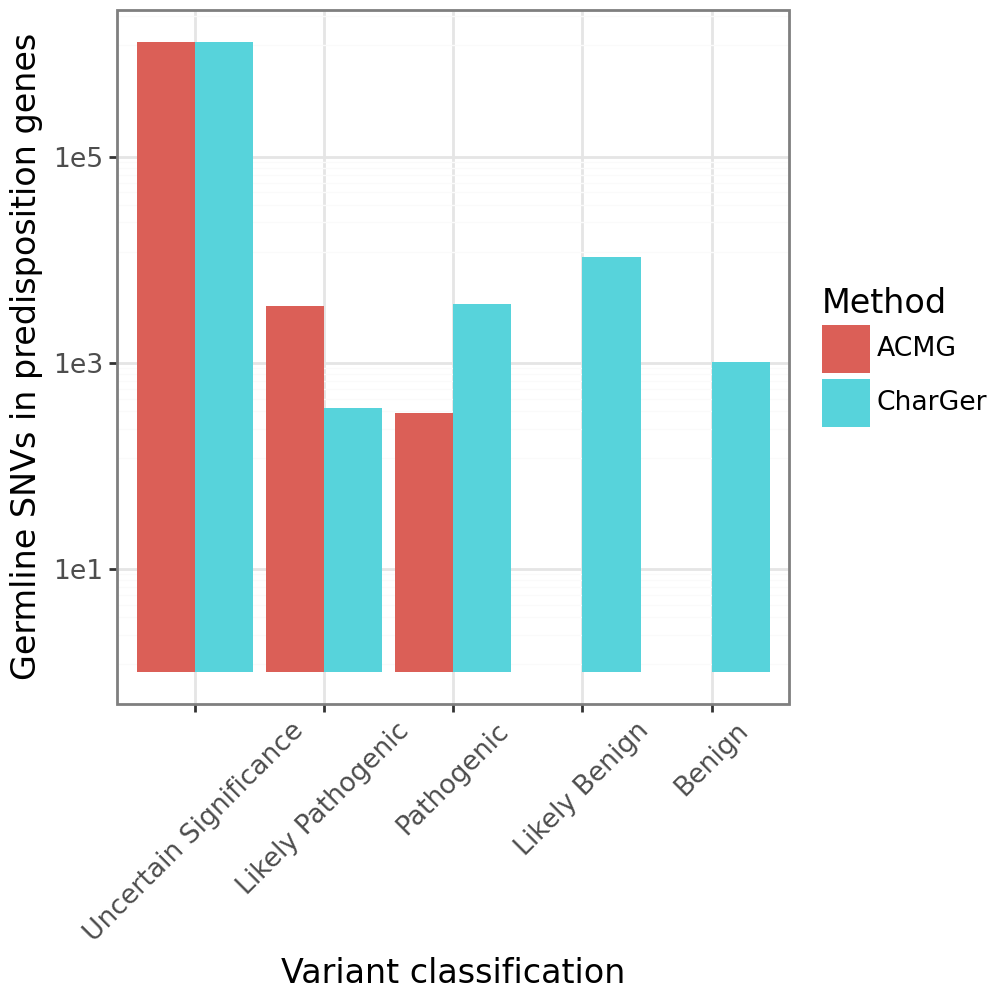

In [80]:
plot_df = germline_snvs.copy()


# 2. Prepare the counts and ensure they are sorted for the bar plot
counts_df = (
    plot_df["CharGer_Classification"]
    .value_counts()
    .reset_index()
)
counts_df.columns = ["Classification", "CharGer"]


acmg_counts = (
    plot_df["ACMG_Classification"]
    .value_counts()
    .reset_index()
)
acmg_counts.columns = ["Classification", "ACMG"]

counts_df = counts_df.merge(acmg_counts, on="Classification", how="left")

# Convert Classification to a categorical type with levels sorted by Count
# This ensures the bars appear in descending order
counts_df["Classification"] = pd.Categorical(
    counts_df["Classification"], 
    categories=counts_df.sort_values("ACMG", ascending=False)["Classification"],
    ordered=True
)

df_long = counts_df.melt(
    id_vars=['Classification'], 
    value_vars=['CharGer', 'ACMG'],
    var_name='Method', 
    value_name='Count'
)

# 2. Plot with Log Scale and Rotated Labels
plot = (
    pn.ggplot(df_long, pn.aes(x='Classification', y='Count', fill='Method'))
    + pn.geom_col(position='dodge') 
    + pn.scale_y_log10()  # This handles the massive range in values
    + pn.theme_bw(base_size=12)
    + pn.theme(figure_size=(5, 5), axis_text_x=pn.element_text(rotation=45))
    + pn.labs(
        x="Variant classification",
        y="Germline SNVs in predisposition genes"
    )
)
plot

### back to code

In [14]:
absplice_predisp = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/resources/predisp_max_abSplice_snvs_hg19.parquet")
        .filter((pl.col("hg19_end").is_in(valid_positions)))
        .collect(engine="streaming")
      ).to_pandas()
absplice_predisp.shape

(1269822, 66)

In [15]:
print(len(germline_snvs))
merged_vars = germline_snvs.merge(absplice_predisp, left_on=["chrom", "POS", "Ref", "Alt"], right_on=["chrom", "hg19_end", "ref", "alt"], how="left")
print(len(merged_vars))
absplice_samples = merged_vars[merged_vars["AbSplice2_max"] >= 0.05]["sampleID"]
# merged_vars.loc[merged_vars["AbSplice2_max"].isna(), "AbSplice2_max"] = 0



2757126
2757247


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [40]:
all_res = []
fr_res_all = []

for cohort in sa[sa["Diag"] != "Unstranded_data"]["Diag"].unique():
    
    fr_res_new =( pl.scan_csv(f"/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/{cohort}/results_gene_all.tsv", 
                                schema_overrides={
                                    "deltaPsi": pl.Float64,
                                    "seqnames": pl.String,
                                }, 
                                null_values=["NA"],
                                 separator="\t")
                    .select("sampleID", "hgncSymbol", "pValue", "padjust", 'seqnames', 'start', 'end', 'strand', 'deltaPsi', 'padjustGene_Genes_to_test_on_all_samples', 'counts', 'totalCounts', 'nonsplitCounts')
                    .filter(pl.col("sampleID").is_in(absplice_samples))
                    .filter(pl.col("hgncSymbol").is_in(genes_of_interest["gene_name"]))
                    .collect(engine="streaming")
                    ).rename({"start": "junction_start", "end": "junction_end"}).to_pandas()
    # fr_res_new[(fr_res_new["padjust"] <= 0.05) & (fr_res_new["padjust_Genes_to_test_on_all_samples"].notna())]
    fr_res_new = fr_res_new.merge(sa, left_on="sampleID", right_on="pid")
    fr_res_new = fr_res_new[(fr_res_new["padjust"] <= 0.1) & (fr_res_new["deltaPsi"].abs() >= 0.1)]
    fr_res_all.append(fr_res_new)

    # fr_res_new["key"] = fr_res_new["sampleID"] +  "." + fr_res_new["nct_pid"].str.split("_").str[1]
    predisp_absplice = merged_vars.merge(fr_res_new, right_on=["sampleID", "hgncSymbol"], left_on=["sampleID", "HUGO_Symbol"], how="inner")
    all_res.append(predisp_absplice)
all_res = pd.concat(all_res)
fr_res_all = pd.concat(fr_res_all)

In [43]:
all_res


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [45]:
all_res["Variant"] = (
    all_res["seqnames_x"] + ":" + 
    all_res["POS"].astype(str) + ":" + 
    all_res["Ref"] + ":" + 
    all_res["Alt"]
)

columns = ["sampleID", "Variant", "junction_start" ,"junction_end", "deltaPsi", "pangolin_score", "AbSplice2_max", "Oncotree Code", "hgncSymbol", "Oncotree Text", "VEP_Most_Severe_Consequence", "VEP_IMPACT", "Diag", "Tumorzellgehalt (Bioinformatik)",  "padjust", "pValue", "ClinVar_Pathogenicity", "ACMG_Classification", "CharGer_Classification",
                 "score_category", "strand", "Tumor_VAF", "Control_VAF", "FILTER" , "counts", "totalCounts", "nonsplitCounts", "nct_pid", "spliceAI_DS_gt_04"]
#   
all_res.drop_duplicates(subset=["sampleID", "hgncSymbol"]) # total number of outliers with germline variant
all_res_splice = all_res[(all_res["AbSplice2_max"] >= 0.05) | (all_res["pangolin_score"] >= 0.2) |(all_res["Consequence"].isin(["splice_acceptor_variant", "splice_donor_variant"])) | (all_res["max_spliceai_score"] >= 0.2)]
all_res_splice[(all_res_splice["totalCounts"] >= 10) & (all_res_splice["POS"] >= all_res_splice["junction_start"] - 500) & (all_res_splice["POS"] <= all_res_splice["junction_end"] + 500)][columns]
# ad_vus_outlier = all_res_splice[(all_res_splice["totalCounts"] >= 10) & (all_res_splice["POS"] >= all_res_splice["junction_start"] - 500) & (all_res_splice["POS"] <= all_res_splice["junction_end"] + 500) & (all_res_splice["hgncSymbol"].isin(AD_inheritence["Approved symbol (HGNC)"]))][columns]
# # ad_vus_outlier
# ad_vus_outlier[(ad_vus_outlier["CharGer_Classification"] != "Pathogenic") & (abs(ad_vus_outlier["deltaPsi"]) >= 0.2)][columns]
# # TODO check unknown significance and 

# ad_vus_outlier[(ad_vus_outlier["CharGer_Classification"] != "Pathogenic") & (abs(ad_vus_outlier["deltaPsi"]) >= 0.2) & (ad_vus_outlier["VEP_Most_Severe_Consequence"] == "intron_variant")][columns]

# ad_vus_outlier[(ad_vus_outlier["CharGer_Classification"] != "Pathogenic")][columns]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [128]:
all_res_splice["sampleID"].unique()

<ArrowStringArray>
['DBHYD2', 'EWZVEU', 'U9755G', 'VMUK3T', '17A8EV', '1D3QG5', '1EWB61',
 '2GABZN', '3EWTYB', '55Z3XD',
 ...
 'SVJNMQ', 'TM2XTW', 'W3ZFUV', 'X9VTWL', 'YWA7WH', '7CCGJ4', 'HE2H4F',
 'UU4FF6', 'VEAUMV', 'W7ENJM']
Length: 175, dtype: str

In [231]:
fr_res =  pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_outliers_variants.tsv", sep="\t")
fr_res = fr_res.merge(sa, left_on="sampleID", right_on="pid")
fr_res = fr_res[fr_res["padjust"] <= 0.05]

In [232]:
predisp_absplice = merged_vars.merge(fr_res, right_on=["sampleID", "hgncSymbol"], left_on=["sampleID", "vep_gene_name"], how="left")



In [23]:
predisp_absplice["Outlier status"] = False
predisp_absplice.loc[predisp_absplice["hgncSymbol"].notna(), "Outlier status"] = True


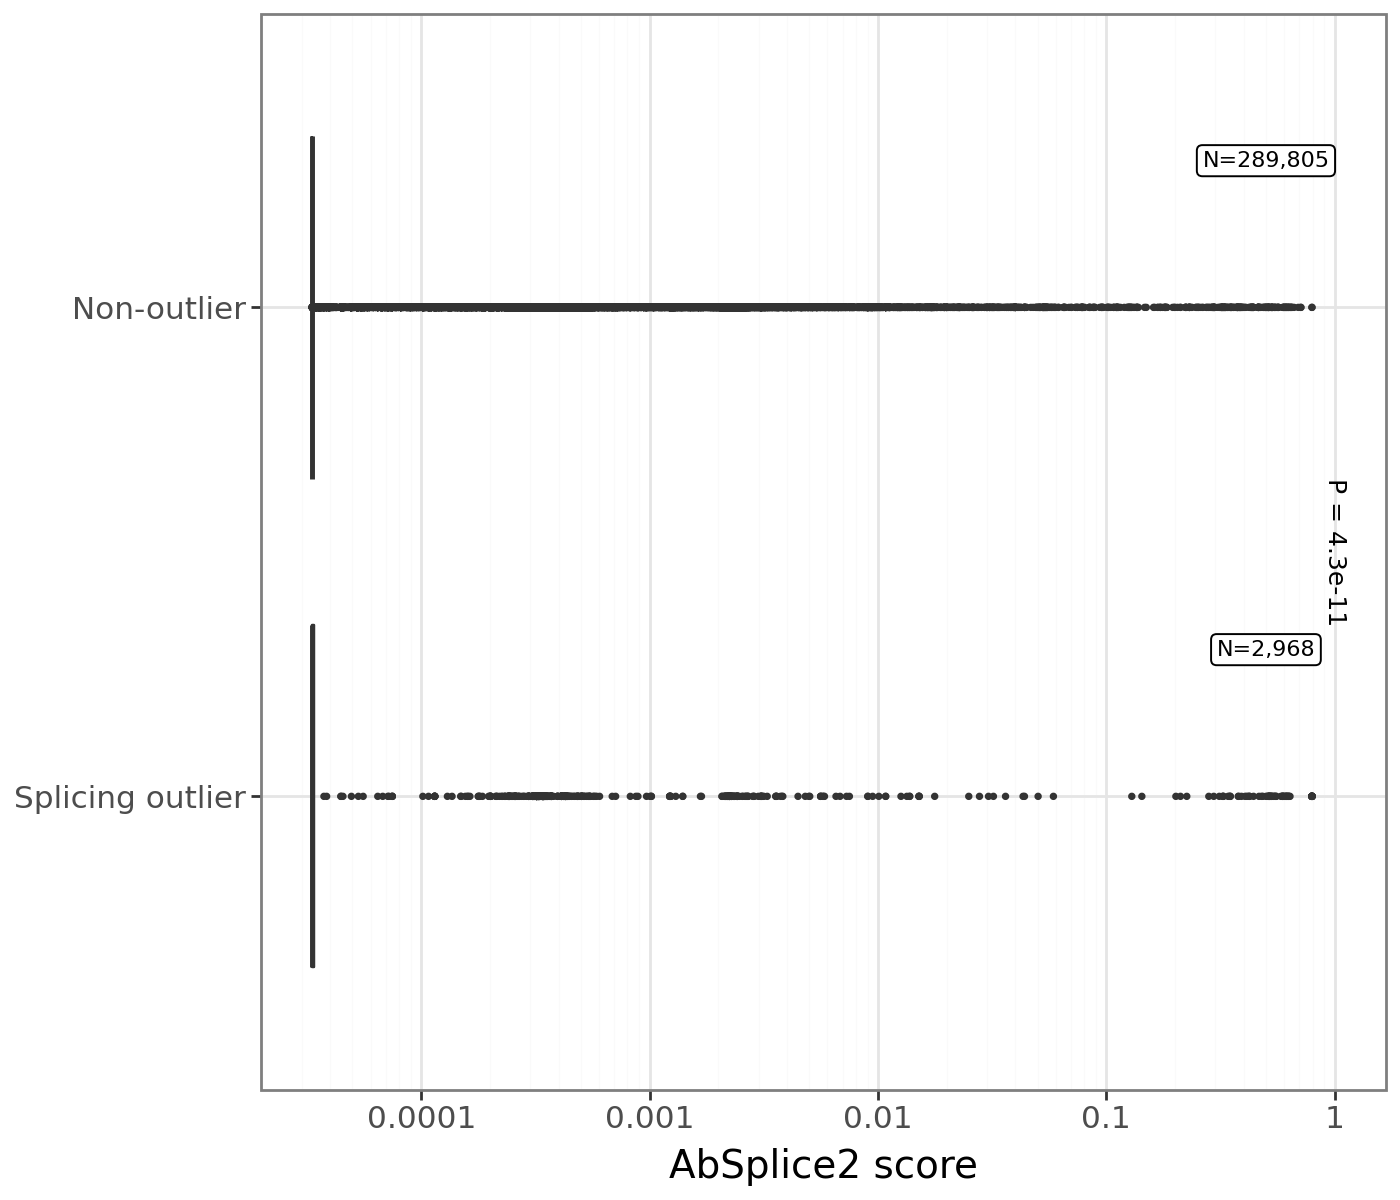

In [241]:

# 1. Categorization
df_plot = predisp_absplice[predisp_absplice["AbSplice2_max"] > 0].copy()
conditions = [
    (df_plot['Outlier status'] == True) ,
    (df_plot['Outlier status'] == False)
]

choices = ['Splicing outlier', 'Non-outlier']
df_plot['plot_group'] = np.select(conditions, choices, default='Non-outlier')

# Order: Over (Bottom/1), Non (Mid/2), Under (Top/3)
group_order = ['Splicing outlier', 'Non-outlier']
df_plot['plot_group'] = pd.Categorical(df_plot['plot_group'], categories=group_order, ordered=True)

# 2. Extract series for stats
over_vals = df_plot[df_plot['plot_group'] == 'Splicing outlier']["AbSplice2_max"]
none_vals = df_plot[df_plot['plot_group'] == 'Non-outlier']["AbSplice2_max"]


# 3. Stats
p_over = mannwhitneyu(over_vals, none_vals, alternative='greater').pvalue if len(over_vals) > 0 else np.nan

def format_p(p):
    return f"P = {p:.1e}" if p < 0.001 else f"P = {p:.4f}"

# 4. Plot
# We define bracket positions. y_pos is the horizontal line location.
y_max = df_plot["AbSplice2_max"].max()
bracket_y = y_max * 1.2  # Position brackets slightly outside the data range

p = (
    pn.ggplot(df_plot, pn.aes(x="plot_group", y="AbSplice2_max", fill="plot_group"))
    + pn.geom_boxplot(outlier_size=0.5, width=0.7)
    + pn.coord_flip()
    + pn.scale_fill_manual(values={"Splicing outlier": "#f8766d", "Non-outlier": "#7f7f7f"}, guide=None)
    + pn.theme_bw(base_size=14)
    + pn.theme(figure_size=(7, 6), axis_title_y=pn.element_blank())
    + pn.labs(y="AbSplice2 score")
    
    # --- Brackets & P-values ---
    
    # Bracket for Overexpressed (x=1) vs Non-outlier (x=2)
    #+ pn.geom_segment(pn.aes(x=1.1, xend=1.9, y=bracket_y, yend=bracket_y)) # Vertical bar (flipped)
    + pn.annotate("text", x=1.5, y=bracket_y * 1.05, label=format_p(p_over), size=9, angle=270)
    
    # --- N Labels ---
    + pn.annotate("label", x=2.3, y=0.5, label=f"N={len(none_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=1.3, y=0.5, label=f"N={len(over_vals):,}", fill="white", size=8)
    + pn.scale_y_log10( labels=custom_format('{:g}'))
    # Expand the plot to make room for brackets
    #+ pn.scale_y_continuous(expand=(0, 0, 0.2, 0)) 
)

p

In [182]:
df_plot[(df_plot["Outlier status"] == True) & (df_plot["AbSplice2_max"] >= 0.05)]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


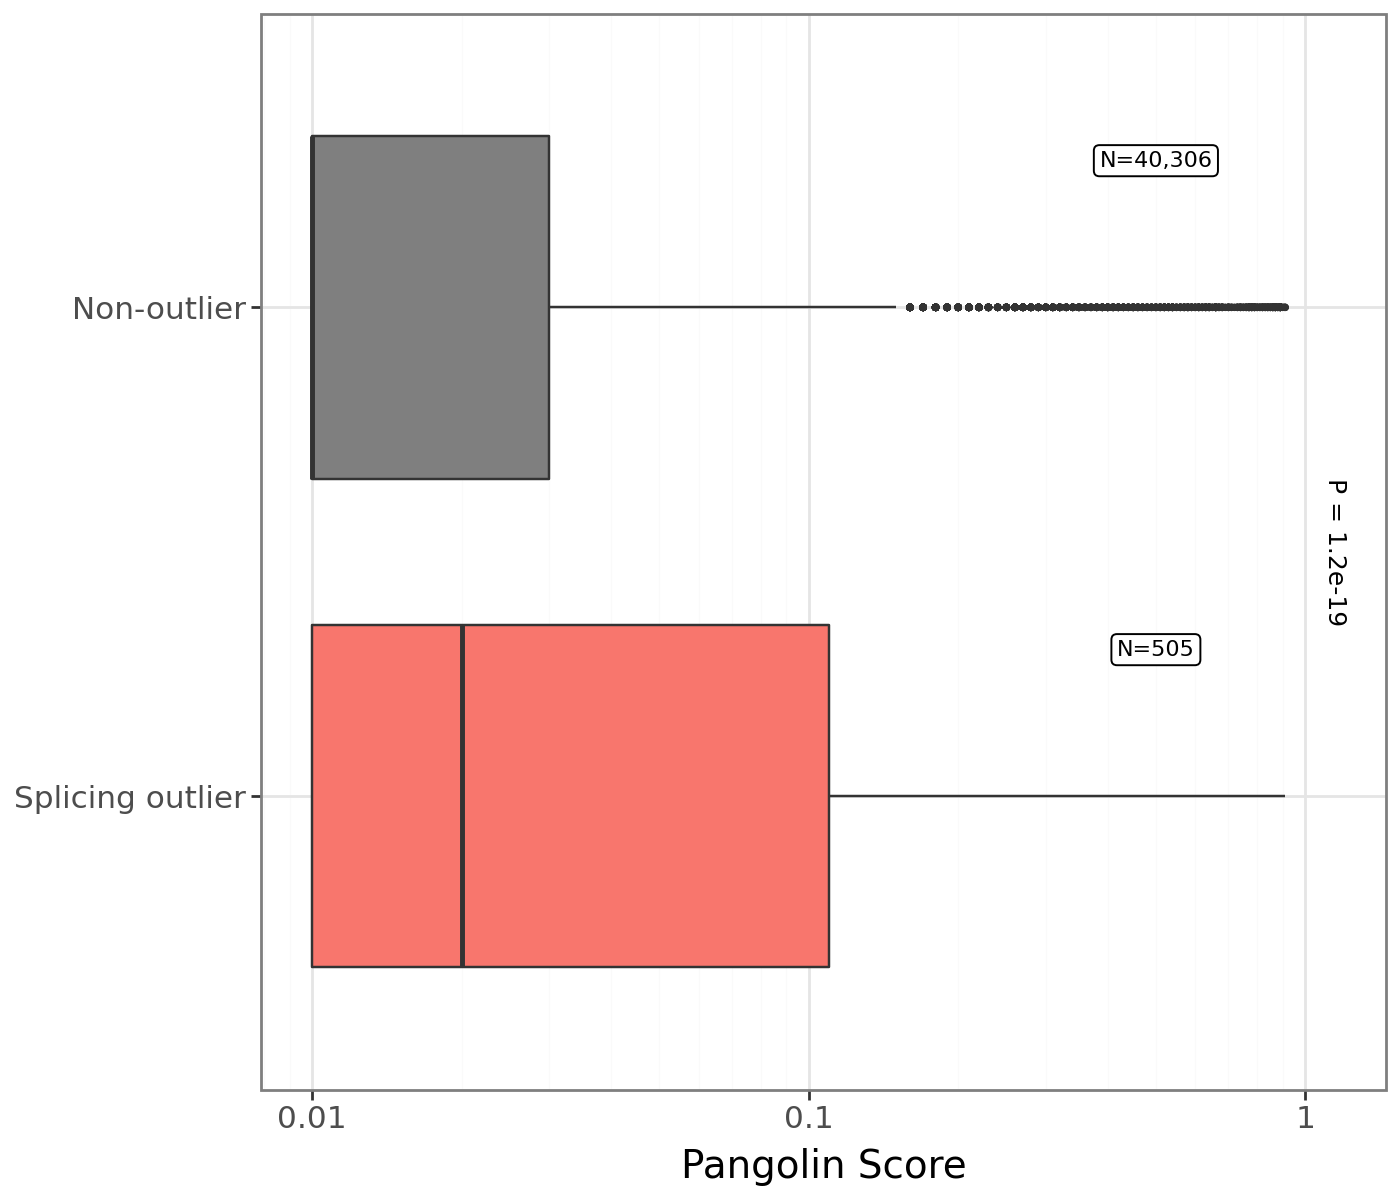

In [240]:
import pandas as pd
import numpy as np
import plotnine as pn
from scipy.stats import mannwhitneyu
from mizani.transforms import pseudo_log_trans

# 1. Categorization
df_plot = predisp_absplice.copy()
df_plot = df_plot[df_plot['pangolin_score']  > 0]
conditions = [
    (df_plot['Outlier status'] == True) ,
    (df_plot['Outlier status'] == False)
]

choices = ['Splicing outlier', 'Non-outlier']
df_plot['plot_group'] = np.select(conditions, choices, default='Non-outlier')

# Order: Over (Bottom/1), Non (Mid/2), Under (Top/3)
group_order = ['Splicing outlier', 'Non-outlier']
df_plot['plot_group'] = pd.Categorical(df_plot['plot_group'], categories=group_order, ordered=True)

# 2. Extract series for stats
over_vals = df_plot[df_plot['plot_group'] == 'Splicing outlier']["pangolin_score"]
none_vals = df_plot[df_plot['plot_group'] == 'Non-outlier']["pangolin_score"]


# 3. Stats
p_over = mannwhitneyu(over_vals, none_vals, alternative='greater').pvalue if len(over_vals) > 0 else np.nan

def format_p(p):
    return f"P = {p:.1e}" if p < 0.001 else f"P = {p:.4f}"

# 4. Plot
# We define bracket positions. y_pos is the horizontal line location.
y_max = df_plot["pangolin_score"].max()
bracket_y = y_max * 1.2  # Position brackets slightly outside the data range

p = (
    pn.ggplot(df_plot, pn.aes(x="plot_group", y="pangolin_score", fill="plot_group"))
    + pn.geom_boxplot(outlier_size=0.5, width=0.7)
    + pn.coord_flip()
    + pn.scale_fill_manual(values={"Splicing outlier": "#f8766d", "Non-outlier": "#7f7f7f"}, guide=None)
    + pn.theme_bw(base_size=14)
    + pn.theme(figure_size=(7, 6), axis_title_y=pn.element_blank())
    + pn.labs(y="Pangolin Score")
    
    # --- Brackets & P-values ---
    
    # Bracket for Overexpressed (x=1) vs Non-outlier (x=2)
    #+ pn.geom_segment(pn.aes(x=1.1, xend=1.9, y=bracket_y, yend=bracket_y)) # Vertical bar (flipped)
    + pn.annotate("text", x=1.5, y=bracket_y * 1.05, label=format_p(p_over), size=9, angle=270)
    
    # --- N Labels ---
    + pn.annotate("label", x=2.3, y=0.5, label=f"N={len(none_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=1.3, y=0.5, label=f"N={len(over_vals):,}", fill="white", size=8)
    # + pn.scale_y_continuous(trans=pseudo_log_trans( sigma=0.1, base=10))
    # Expand the plot to make room for brackets
    #+ pn.scale_y_continuous(expand=(0, 0, 0.2, 0)) 
        + pn.scale_y_log10( labels=custom_format('{:g}'))

)

p

In [34]:
fr_res.columns

Index(['seqnames', 'start', 'end', 'width', 'strand', 'sampleID', 'hgncSymbol',
       'type', 'pValue', 'padjust', 'psiValue', 'deltaPsi', 'counts',
       'totalCounts', 'meanCounts', 'meanTotalCounts', 'nonsplitCounts',
       'nonsplitProportion', 'nonsplitProportion_99quantile',
       'annotatedJunction', 'pValueGene', 'padjustGene', 'potentialImpact',
       'causesFrameshift', 'UTR_overlap', 'blacklist', 'Diag_x',
       'distNearestGene', 'gene_name', 'geneID_short', 'geneID', 'Gene',
       'IMPACT_snv', 'Consequence_snv', 'ANNOTATION_control_snv',
       'promoterAI_snv', 'Location_snv', 'alt_snv', 'ref_snv',
       '#Uploaded_variation_snv', 'IMPACT_indel', 'Consequence_indel',
       'ANNOTATION_control_indel', 'Location_indel', 'variant_type', 'IMPACT',
       '#Uploaded_variation_indel', 'chrom_indel', 'pos_indel', 'ref_indel',
       'alt_indel', 'Unnamed: 0', 'pid', 'Oncotree Code', 'SEX', 'Birthdate',
       'Deathdate', 'Date of Diagnosis', 'ICD10 Code', 'freitext',


In [24]:
columns = ["group_name", "seqnames_x", "start_x", "end_x", "Ref", "Alt", "Gene_x", "Location", "Function", "Tumorzellgehalt (Bioinformatik)", "potentialImpact", "Oncotree Code", "padjust",
           "CharGer_Score", "ACMG_Classification", "CharGer_Classification", "spliceAI_DS_gt_04", "pangolin_score", "AbSplice2_max", "score_category", "Consequence_snv", "ANNOTATION_control_snv", "IMPACT_snv", "start", "end", "strand_y", "deltaPsi" ]

In [25]:
predisp_outlier_germline = predisp_absplice[predisp_absplice["Outlier status"] == True]
a = predisp_outlier_germline[(predisp_outlier_germline["pangolin_score"] >= 0.2) | (predisp_outlier_germline["AbSplice2_max"] >= 0.05)][columns]

a[a["Gene_x"].isin(AD_inheritence["Approved symbol (HGNC)"])][columns]

KeyError: "['Gene_x', 'potentialImpact', 'Consequence_snv', 'ANNOTATION_control_snv', 'IMPACT_snv', 'start', 'end'] not in index"

In [ ]:
predisp_outlier_germline[columns].sort_values("AbSplice2_max", ascending=False)

In [ ]:
plot_df = predisp_outlier_germline[
    (predisp_outlier_germline["Outlier status"] == True)
].copy()

# 2. Prepare the counts and ensure they are sorted for the bar plot
counts_df = (
    plot_df["CharGer_Classification"]
    .value_counts()
    .reset_index()
)
counts_df.columns = ["Classification", "Count"]

# Convert Classification to a categorical type with levels sorted by Count
# This ensures the bars appear in descending order
counts_df["Classification"] = pd.Categorical(
    counts_df["Classification"], 
    categories=counts_df.sort_values("Count", ascending=False)["Classification"],
    ordered=True
)

# 3. Create the Plot
p = (
    pn.ggplot(counts_df, pn.aes(x="Classification", y="Count", fill="Classification"))
    + pn.geom_col(show_legend=False)
    + pn.theme_bw()
    + pn.theme(
        figure_size=(6, 5),
        axis_text_x=pn.element_text(rotation=45), # Rotates labels
        panel_grid_major_x=pn.element_blank()
    )
    + pn.labs(
        x="CharGer Classification",
        y="Number of germilne SNVs in splicing outliers"
    )
    #+ pn.scale_fill_brewer(type="qual", palette="Set3") # Nice color palette
)
p

In [22]:
predisp_outlier_germline[predisp_outlier_germline["ANNOTATION_control_snv"] == "somatic"]

NameError: name 'predisp_outlier_germline' is not defined

In [58]:
predisp_outlier_germline[(predisp_outlier_germline["pangolin_score"] >= 0.2) & (predisp_outlier_germline["Consequence_snv"].str.contains("intron"))][columns]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [59]:
predisp_outlier_germline[(predisp_outlier_germline["pangolin_score"] >= 0.2) ]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [17]:
df_final = pl.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/predisp/predisp_splicing_snvs.tsv", separator="\t")

df_final_indels = pl.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/predisp/predisp_splicing_indels.tsv", separator="\t")


df_final = df_final.with_columns(type = pl.lit("snv"))
df_final_indels = df_final_indels.with_columns(type = pl.lit("indel"))

# Now use the "relaxed" concat to handle the SchemaError you had earlier
all_vars = pl.concat([df_final, df_final_indels], how="diagonal_relaxed").to_pandas()


In [21]:
fr_res_vars = fr_res.merge(all_vars, left_on=["sampleID", "hgncSymbol"], right_on=["sampleID", "SYMBOL"])

In [24]:
c = fr_res_vars[(fr_res_vars["IMPACT_x"].notna()) & 
           ((fr_res_vars["ANNOTATION_control_snv"].str.contains("germline", na=False)) |
            (fr_res_vars["ANNOTATION_control_indel"].str.contains("germline", na=False)))]
c["var_pos"] = c["Location"].str.split(":").str[1]
c['var_pos_mid'] = c['var_pos'].apply(get_midpoint)
c["sampleID"].value_counts()
#c[c["IMPACT_y"] != "HIGH"] # non-canonical


# c[(c["IMPACT_y"] != "HIGH")]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [61]:
c[(c["IMPACT_y"] != "HIGH") & (c["Consequence"].str.contains("intron_variant")) & (c["max_spliceai_score"] >= 0.2) & (c["var_pos_mid"] >= c["start"] - 20) & (c["var_pos_mid"] <= c["end"] + 20) ][["sampleID", "AF", "Consequence", "SYMBOL", "IMPACT_y", 
                                                                                                                     "start", "end", "deltaPsi",  "max_spliceai_score", "potentialImpact",
                                                                                                                    "Location", "nonsplitCounts", "Allele"]]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [60]:
all_vars.filter(pl.col("Location") == "10:89708887")

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [33]:
c[(c["IMPACT_y"] != "HIGH") & (c["Consequence"].str.contains("intron_variant")) & (c["max_spliceai_score"] >= 0.2)][["sampleID", "AF", "Consequence", "SYMBOL", "IMPACT_y", 


In [42]:
c[["Location", "start", "end", "var_pos", "var_pos_mid"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# check zygosity

In [81]:
file_path = "/omics/odcf/analysis/hipo/hipo_021/GermlineAnalysis/data_object_master_germline/sequencing/whole_genome_sequencing/results_per_pid/H021-GPCJUP/germline_smallVariants.tumor.blood/v3.0.0/smallVariants_H021-GPCJUP.clean_annotated.rare.VEP.CharGer.TiNDA.rare_germline.vcf"
df = pl.read_csv(file_path, separator="\t", comment_prefix="##", infer_schema_length=20000000)
df.filter(pl.col("POS") == 44255793)[["sample_blood_H021-GPCJUP"]]
df.filter(pl.col("POS") == 44255793)[["sample_blood_H021-GPCJUP"]]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
